# MLOps Project – Phase 2: Experiment Tracking & Model Registry with MLflow

**Dataset:** `global_fuel_prices_2020_2026.csv`  
**Target:** `petrol_usd_liter`  
**Preprocessing:** identical to Phase 1 (`pipeline.py`) — date feature extraction, median imputation, StandardScaler, OneHotEncoder(drop='first')

---

### Before running
Start the MLflow tracking server in a **separate terminal**:
```bash
mlflow ui
# → http://localhost:5000
```
Make sure `global_fuel_prices_2020_2026.csv` and `pipeline.py` are in the same directory as this notebook.

## 1. Imports & MLflow Configuration

In [3]:
import warnings
warnings.filterwarnings('ignore')

import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 110

# Phase 1 helpers — reuse identical preprocessing
sys.path.insert(0, str(Path.cwd()))
from pipeline import (
    find_project_root, resolve_notebook_dir,
    convert_numeric_like_objects, add_date_features,
    resolve_target_column, infer_columns_to_drop,
    build_model, DATA_FILENAME
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

print(f'MLflow {mlflow.__version__} ready.')

MLflow 3.11.1 ready.


In [4]:
import warnings
warnings.filterwarnings('ignore')

import sys, json
import subprocess
import time
import requests
from pathlib import Path

TRACKING_URI    = 'http://localhost:5000'
EXPERIMENT_NAME = 'GlobalFuelPrice'
REGISTRY_NAME   = 'BestFuelRegressor_v1'
TEST_SIZE       = 0.2
RANDOM_STATE    = 42

# Function to check if MLflow server is running
def is_mlflow_server_running():
    try:
        response = requests.get(f"{TRACKING_URI}/health", timeout=2)
        return response.status_code == 200
    except:
        return False

# Start MLflow server if not running
if not is_mlflow_server_running():
    print("MLflow server not running. Starting...")
    
    # Create mlruns directory if it doesn't exist
    Path("mlruns").mkdir(exist_ok=True)
    
    # Start server in background (platform-specific)
    import platform
    if platform.system() == "Windows":
        subprocess.Popen(
            ["start", "cmd", "/c", "mlflow", "server", "--host", "localhost", "--port", "5000"],
            shell=True
        )
    else:  # Linux/Mac
        subprocess.Popen(
            ["mlflow", "server", "--host", "localhost", "--port", "5000"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            start_new_session=True
        )
    
    # Wait for server to start
    print("Waiting for server to start...")
    for i in range(10):
        time.sleep(1)
        if is_mlflow_server_running():
            print("MLflow server started successfully!")
            break
    else:
        print("Warning: Could not verify server started. Continuing anyway...")

import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri(TRACKING_URI)

# Create experiment if it doesn't exist
try:
    mlflow.create_experiment(EXPERIMENT_NAME)
    print(f"Created experiment: {EXPERIMENT_NAME}")
except:
    pass  # Experiment already exists

mlflow.set_experiment(EXPERIMENT_NAME)

print(f'Tracking URI : {TRACKING_URI}')
print(f'Experiment   : {EXPERIMENT_NAME}')
print(f'MLflow version: {mlflow.__version__}')

Tracking URI : http://localhost:5000
Experiment   : GlobalFuelPrice
MLflow version: 3.11.1


## 2. Data Loading & Preprocessing

Mirrors `pipeline.py::run_analysis()` exactly — same feature engineering, same split.

In [6]:
project_dir = find_project_root()
data_path   = project_dir / DATA_FILENAME

df         = pd.read_csv(data_path)
working_df = convert_numeric_like_objects(df)
date_cols  = add_date_features(working_df)

target_col      = resolve_target_column(working_df)
cols_to_drop    = infer_columns_to_drop(working_df, target_col, date_cols)

working_df = working_df.drop(columns=cols_to_drop, errors='ignore')
working_df = working_df.dropna(subset=[target_col]).copy()

y = pd.to_numeric(working_df[target_col], errors='coerce')
X = working_df.drop(columns=[target_col]).copy()

mask = y.notna()
X, y = X.loc[mask].copy(), y.loc[mask].copy()
X = X.drop(columns=[c for c in X.columns if X[c].isna().all()], errors='ignore')

NUMERIC_FEATURES     = X.select_dtypes(include=['number', 'bool']).columns.tolist()
CATEGORICAL_FEATURES = [c for c in X.columns if c not in NUMERIC_FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Target      : {target_col}')
print(f'Dropped     : {cols_to_drop}')
print(f'Rows        : {len(X)} total  |  {len(X_train)} train  |  {len(X_test)} test')
print(f'Numeric     : {NUMERIC_FEATURES}')
print(f'Categorical : {CATEGORICAL_FEATURES}')

Target      : petrol_usd_liter
Dropped     : ['date', 'diesel_usd_liter', 'lpg_usd_liter']
Rows        : 27468 total  |  21974 train  |  5494 test
Numeric     : ['brent_crude_usd', 'tax_percentage', 'date_year', 'date_month', 'date_weekofyear']
Categorical : ['country', 'region', 'income_level', 'subsidy_level']


## 3. Exploratory Data Analysis

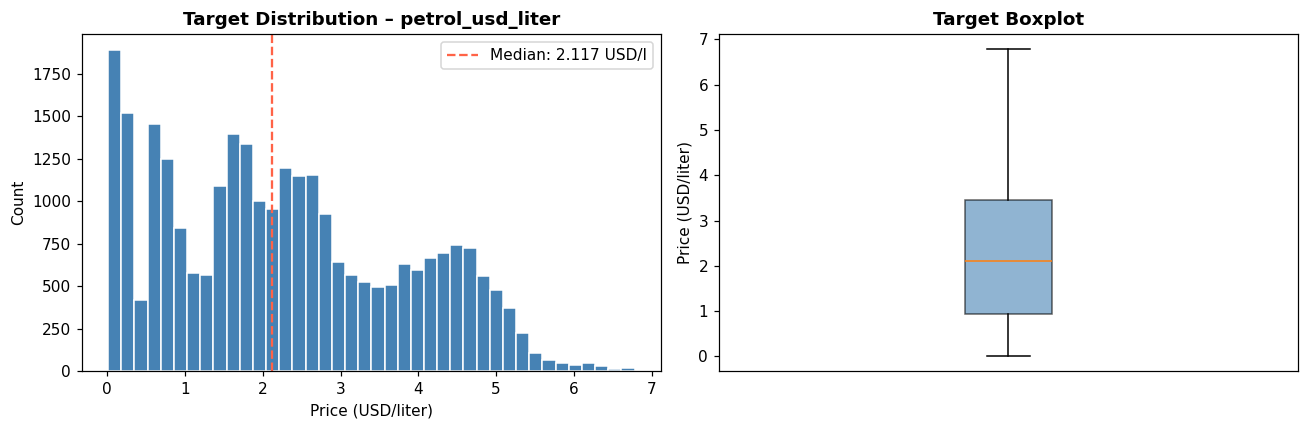

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(y.median(), color='tomato', linestyle='--',
                label=f'Median: {y.median():.3f} USD/l')
axes[0].set_title('Target Distribution – petrol_usd_liter', fontweight='bold')
axes[0].set_xlabel('Price (USD/liter)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Target Boxplot', fontweight='bold')
axes[1].set_ylabel('Price (USD/liter)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('eda_target.png', bbox_inches='tight')
plt.show()

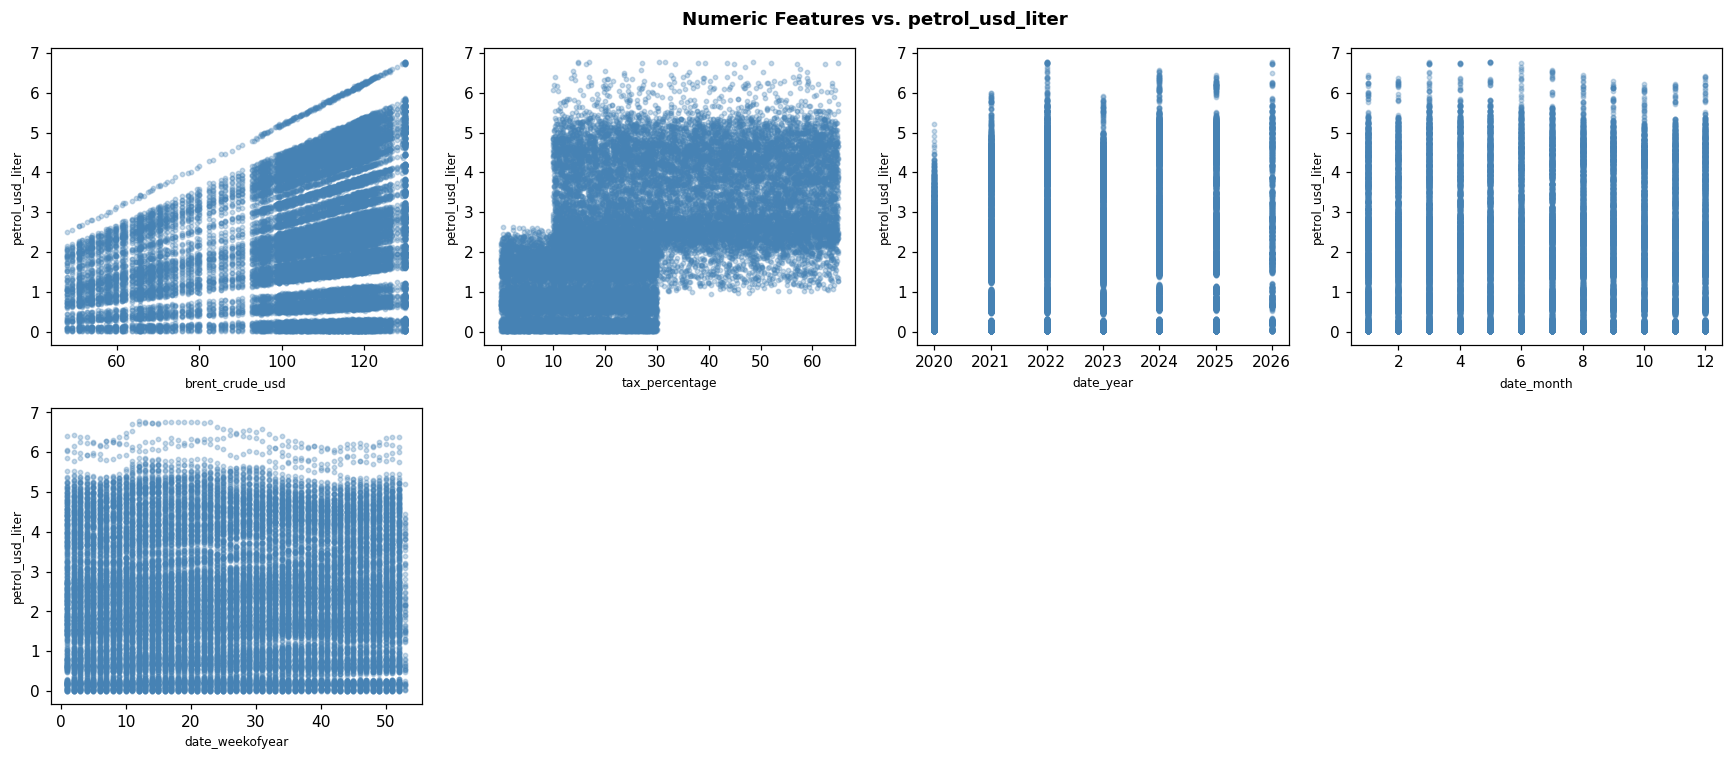

In [9]:
if NUMERIC_FEATURES:
    n    = len(NUMERIC_FEATURES)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = np.array(axes).flatten()

    for i, feat in enumerate(NUMERIC_FEATURES):
        axes[i].scatter(X[feat], y, alpha=0.3, s=8, color='steelblue')
        axes[i].set_xlabel(feat, fontsize=8)
        axes[i].set_ylabel(target_col, fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Numeric Features vs. {target_col}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_scatter.png', bbox_inches='tight')
    plt.show()

## 4. Bonus – Confidence Intervals with statsmodels

A statsmodels OLS is fit on the **scaled numeric features** (same scaler as Phase 1) to produce 95% prediction confidence intervals. Artefacts are logged with every MLflow run and reused in Phase 3.

In [11]:
# Fit Phase-1-identical pipeline once to extract the fitted scaler
_ref_pipe = build_model(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
_ref_pipe.fit(X_train, y_train)
_preprocessor = _ref_pipe.named_steps['preprocessor']

if NUMERIC_FEATURES:
    _num_t       = _preprocessor.named_transformers_['num']
    X_train_num  = _num_t.transform(X_train[NUMERIC_FEATURES])
    X_test_num   = _num_t.transform(X_test[NUMERIC_FEATURES])
    X_train_sm   = sm.add_constant(X_train_num)
    X_test_sm    = sm.add_constant(X_test_num)
    ols_model    = sm.OLS(y_train.values, X_train_sm).fit()
    print(ols_model.summary())
else:
    ols_model = None
    print('No numeric features — OLS CI skipped.')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     2271.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:37:22   Log-Likelihood:                -36008.
No. Observations:               21974   AIC:                         7.203e+04
Df Residuals:                   21968   BIC:                         7.208e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2754      0.008    270.730      0.0

Coefficient 95% CIs:
                 CI_lower  CI_upper  coefficient
const             2.25894   2.29189      2.27541
brent_crude_usd   0.38246   0.42969      0.40607
tax_percentage    0.78417   0.81712      0.80065
date_year        -0.03049   0.01684     -0.00682
date_month       -0.07267   0.04902     -0.01182
date_weekofyear  -0.04834   0.07329      0.01248


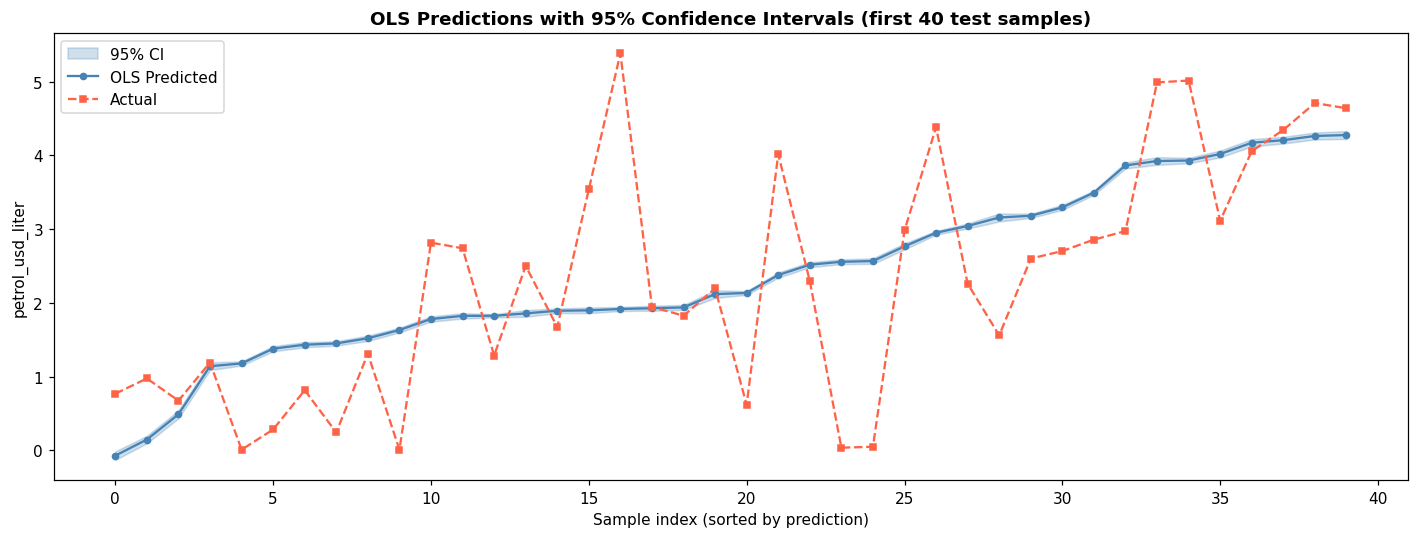

Saved: conf_intervals.csv, prediction_ci.csv, ci_plot.png


In [12]:
if ols_model is not None:
    # Get confidence intervals as DataFrame if possible
    try:
        # Try to get as DataFrame with proper index
        ci_coef = pd.DataFrame(
            ols_model.conf_int(0.05),
            index=['const'] + NUMERIC_FEATURES,
            columns=['CI_lower', 'CI_upper']
        )
    except (AttributeError, ValueError):
        # If that fails, work with numpy array
        ci_coef = pd.DataFrame(
            ols_model.conf_int(0.05),
            columns=['CI_lower', 'CI_upper']
        )
        # Try to assign index if lengths match
        expected_index = ['const'] + NUMERIC_FEATURES
        if len(ci_coef) == len(expected_index):
            ci_coef.index = expected_index
        else:
            print(f"Warning: Expected {len(expected_index)} coefficients but got {len(ci_coef)}")
            ci_coef.index = [f'coef_{i}' for i in range(len(ci_coef))]
    
    # Add coefficients
    ci_coef['coefficient'] = ols_model.params
    
    # Save to CSV
    ci_coef.to_csv('conf_intervals.csv')
    print('Coefficient 95% CIs:')
    print(ci_coef.round(5))
    
    # Get predictions with confidence intervals
    pred_sm = ols_model.get_prediction(X_test_sm)
    ci_df = pred_sm.summary_frame(alpha=0.05)[['mean', 'mean_ci_lower', 'mean_ci_upper']].copy()
    ci_df.columns = ['predicted', 'ci_lower', 'ci_upper']
    ci_df['actual'] = y_test.values
    ci_df.to_csv('prediction_ci.csv', index=False)
    
    # Plot first 40 predictions
    n = min(40, len(ci_df))
    fig, ax = plt.subplots(figsize=(13, 5))
    
    # Sort by predicted value for better visualization (optional)
    plot_df = ci_df.iloc[:n].sort_values('predicted')
    
    ax.fill_between(
        range(n), 
        plot_df['ci_lower'].values, 
        plot_df['ci_upper'].values,
        alpha=0.25, 
        color='steelblue', 
        label='95% CI'
    )
    ax.plot(range(n), plot_df['predicted'].values, 'o-', color='steelblue',
            lw=1.5, ms=4, label='OLS Predicted')
    ax.plot(range(n), plot_df['actual'].values, 's--', color='tomato',
            lw=1.5, ms=4, label='Actual')
    ax.set_xlabel('Sample index (sorted by prediction)')
    ax.set_ylabel('petrol_usd_liter')
    ax.set_title('OLS Predictions with 95% Confidence Intervals (first 40 test samples)',
                 fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('ci_plot.png', bbox_inches='tight')
    plt.show()
    print('Saved: conf_intervals.csv, prediction_ci.csv, ci_plot.png')

## 5. MLflow Helper Functions

In [14]:
def compute_metrics(y_true, y_pred):
    return {
        'MAE' : float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2'  : float(r2_score(y_true, y_pred)),
    }


def plot_residuals(y_true, y_pred, model_name):
    residuals = np.array(y_true) - np.array(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(residuals, bins=40, color='steelblue', edgecolor='white')
    axes[0].axvline(0, color='tomato', linestyle='--')
    axes[0].set_title(f'{model_name} – Residual Distribution')
    axes[0].set_xlabel('Residual (USD/liter)')
    axes[0].set_ylabel('Frequency')
    axes[1].scatter(y_pred, residuals, alpha=0.35, s=8, color='steelblue')
    axes[1].axhline(0, color='tomato', linestyle='--')
    axes[1].set_title(f'{model_name} – Residuals vs. Fitted')
    axes[1].set_xlabel('Fitted Value')
    axes[1].set_ylabel('Residual')
    plt.tight_layout()
    fname = f'residuals_{model_name.replace(" ","_")}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.close()
    return fname


def plot_actual_vs_predicted(y_true, y_pred, model_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.35, s=8, color='steelblue')
    mn = min(float(np.min(y_true)), float(np.min(y_pred)))
    mx = max(float(np.max(y_true)), float(np.max(y_pred)))
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual (USD/liter)')
    ax.set_ylabel('Predicted (USD/liter)')
    ax.set_title(f'{model_name} – Actual vs. Predicted', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    fname = f'actual_vs_pred_{model_name.replace(" ","_")}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.close()
    return fname


def make_pipeline(model_obj, numeric_feats, categorical_feats):
    """Build the same pipeline structure as Phase 1's build_model()."""
    transformers = []
    if numeric_feats:
        num_t = Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler',  StandardScaler())])
        transformers.append(('num', num_t, numeric_feats))
    if categorical_feats:
        try:
            enc = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        except TypeError:
            enc = OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)
        cat_t = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('encoder', enc)])
        transformers.append(('cat', cat_t, categorical_feats))
    preprocessor = ColumnTransformer(transformers)
    return Pipeline([('preprocessor', preprocessor), ('regressor', model_obj)])


def run_mlflow_experiment(model_obj, model_name, extra_params,
                          X_tr, X_te, y_tr, y_te,
                          numeric_feats, categorical_feats,
                          dataset_version='v1.0'):
    pipeline = make_pipeline(model_obj, numeric_feats, categorical_feats)

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.set_tag('algorithm',       model_name)
        mlflow.set_tag('dataset_version', dataset_version)
        mlflow.set_tag('target',          target_col)

        mlflow.log_param('test_size',              TEST_SIZE)
        mlflow.log_param('random_state',           RANDOM_STATE)
        mlflow.log_param('n_numeric_features',     len(numeric_feats))
        mlflow.log_param('n_categorical_features', len(categorical_feats))
        for k, v in extra_params.items():
            mlflow.log_param(k, v)

        pipeline.fit(X_tr, y_tr)
        y_pred  = pipeline.predict(X_te)
        metrics = compute_metrics(y_te, y_pred)
        for k, v in metrics.items():
            mlflow.log_metric(k, v)

        mlflow.log_artifact(plot_residuals(y_te, y_pred, model_name))
        mlflow.log_artifact(plot_actual_vs_predicted(y_te, y_pred, model_name))

        for ci_file in ('conf_intervals.csv', 'prediction_ci.csv', 'ci_plot.png'):
            if Path(ci_file).exists():
                mlflow.log_artifact(ci_file)

        mlflow.sklearn.log_model(pipeline, artifact_path='model')
        run_id = run.info.run_id

    print(f'  [{model_name:30s}]  '
          f'MAE={metrics["MAE"]:.4f}  '
          f'RMSE={metrics["RMSE"]:.4f}  '
          f'R²={metrics["R2"]:.4f}  '
          f'run_id={run_id[:8]}…')
    return run_id, metrics


print('Helper functions defined.')

Helper functions defined.


## 6. Experiment Runs – Model Comparison

Five configurations across four algorithm families. All share the **same Phase-1-identical preprocessor**.

| # | Algorithm | Key hyperparameter |
|---|-----------|-------------------|
| 1 | LinearRegression | — (baseline, identical to Phase 1) |
| 2 | Ridge | α = 0.5 |
| 3 | Ridge | α = 5.0 |
| 4 | Lasso | α = 0.001 |
| 5 | RandomForestRegressor | 300 trees, max_depth=12 |

In [16]:
experiments = [
    (LinearRegression(),
     'LinearRegression',     {}),
    (Ridge(alpha=0.5),
     'Ridge_alpha0.5',       {'alpha': 0.5}),
    (Ridge(alpha=5.0),
     'Ridge_alpha5',         {'alpha': 5.0}),
    (Lasso(alpha=0.001, max_iter=10_000),
     'Lasso_alpha0.001',     {'alpha': 0.001, 'max_iter': 10_000}),
    (RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE),
     'RandomForest_300trees',{'n_estimators': 300, 'max_depth': 12}),
]

results = {}
print(f'Running {len(experiments)} experiments…\n')

for model_obj, name, params in experiments:
    run_id, metrics = run_mlflow_experiment(
        model_obj, name, params,
        X_train, X_test, y_train, y_test,
        NUMERIC_FEATURES, CATEGORICAL_FEATURES
    )
    results[name] = {'run_id': run_id, **metrics}

print('\nAll runs complete. Open http://localhost:5000 to explore.')

Running 5 experiments…



2026/04/20 21:37:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 21:37:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LinearRegression at: http://localhost:5000/#/experiments/1/runs/4cabcbbfebce427d8ffaae98321f73d2
🧪 View experiment at: http://localhost:5000/#/experiments/1
  [LinearRegression              ]  MAE=0.1677  RMSE=0.2600  R²=0.9724  run_id=4cabcbbf…


2026/04/20 21:37:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 21:37:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Ridge_alpha0.5 at: http://localhost:5000/#/experiments/1/runs/cde20990974e46c4b0b9be310a7427e9
🧪 View experiment at: http://localhost:5000/#/experiments/1
  [Ridge_alpha0.5                ]  MAE=0.1678  RMSE=0.2600  R²=0.9724  run_id=cde20990…


...

🏃 View run Ridge_alpha5 at: http://localhost:5000/#/experiments/1/runs/cb4a4e03c6dc45a1b905d4892734b5d3
🧪 View experiment at: http://localhost:5000/#/experiments/1
  [Ridge_alpha5                  ]  MAE=0.1683  RMSE=0.2602  R²=0.9724  run_id=cb4a4e03…


2026/04/20 21:37:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 21:37:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Lasso_alpha0.001 at: http://localhost:5000/#/experiments/1/runs/4946991209bf43e5b8c862b5aa08b112
🧪 View experiment at: http://localhost:5000/#/experiments/1
  [Lasso_alpha0.001              ]  MAE=0.1881  RMSE=0.2722  R²=0.9698  run_id=49469912…


2026/04/20 21:38:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 21:38:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_300trees at: http://localhost:5000/#/experiments/1/runs/a4ccb31a3be24c36857141f025fa0c4f
🧪 View experiment at: http://localhost:5000/#/experiments/1
  [RandomForest_300trees         ]  MAE=0.0588  RMSE=0.1019  R²=0.9958  run_id=a4ccb31a…

All runs complete. Open http://localhost:5000 to explore.


## 7. Results Summary & Best Model Selection

In [18]:
results_df = pd.DataFrame(results).T
for col in ('MAE', 'RMSE', 'R2'):
    results_df[col] = results_df[col].astype(float)
results_df = results_df.sort_values('RMSE')

print('=' * 72)
print('MODEL COMPARISON  (sorted by RMSE ascending — lower = better)')
print('=' * 72)
print(results_df[['MAE', 'RMSE', 'R2']].to_string(float_format=lambda x: f'{x:.6f}'))

best_name   = results_df.index[0]
best_run_id = results_df.loc[best_name, 'run_id']

print(f'\n✅ Best model : {best_name}')
print(f'   Run ID     : {best_run_id}')
print(f'   RMSE       : {results_df.loc[best_name, "RMSE"]:.6f} USD/liter')
print(f'   R²         : {results_df.loc[best_name, "R2"]:.4f}')

MODEL COMPARISON  (sorted by RMSE ascending — lower = better)
                           MAE     RMSE       R2
RandomForest_300trees 0.058803 0.101875 0.995765
LinearRegression      0.167708 0.259969 0.972424
Ridge_alpha0.5        0.167762 0.259987 0.972420
Ridge_alpha5          0.168308 0.260216 0.972372
Lasso_alpha0.001      0.188150 0.272243 0.969758

✅ Best model : RandomForest_300trees
   Run ID     : a4ccb31a3be24c36857141f025fa0c4f
   RMSE       : 0.101875 USD/liter
   R²         : 0.9958


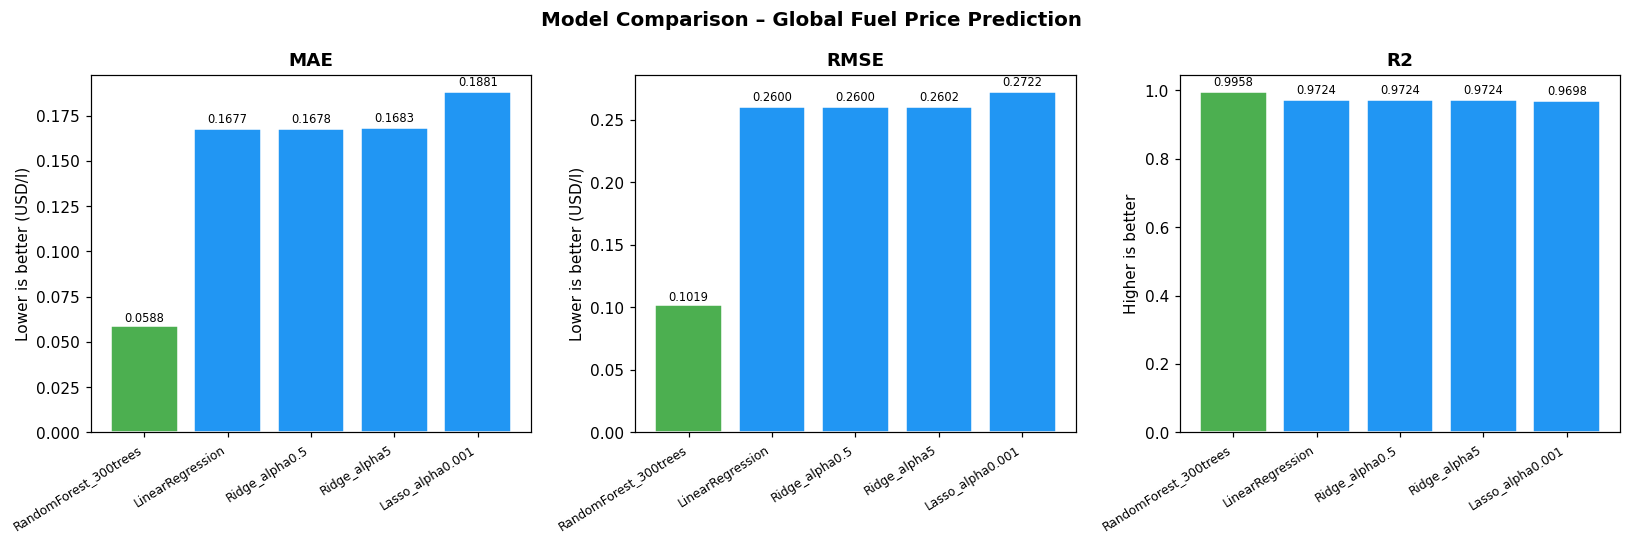

Saved model_comparison.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = results_df.index.tolist()
colors = ['#4CAF50' if m == best_name else '#2196F3' for m in models]

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = results_df[metric].astype(float).tolist()
    bars = ax.bar(range(len(models)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=32, ha='right', fontsize=8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    unit = ' (USD/l)' if metric in ('MAE', 'RMSE') else ''
    ax.set_ylabel(('Lower is better' if metric != 'R2' else 'Higher is better') + unit)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Model Comparison – Global Fuel Price Prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved model_comparison.png')

## 8. Register Best Model in MLflow Model Registry

In [21]:
import time

registered = mlflow.register_model(
    model_uri=f'runs:/{best_run_id}/model',
    name=REGISTRY_NAME
)
print(f'Registered : {registered.name}  v{registered.version}  ({registered.status})')

time.sleep(3)

client = MlflowClient()
client.transition_model_version_stage(
    name=REGISTRY_NAME,
    version=int(registered.version),
    stage='Production',
    archive_existing_versions=True
)
print(f'Version {registered.version} → Production ✅')

Registered model 'BestFuelRegressor_v1' already exists. Creating a new version of this model...
2026/04/20 21:38:14 WARNING mlflow.tracking._model_registry.fluent: Run with id a4ccb31a3be24c36857141f025fa0c4f has no artifacts at artifact path 'model', registering model based on models:/m-1ba8345e0fe6484c9d5bf3b64155ab47 instead
2026/04/20 21:38:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BestFuelRegressor_v1, version 2
Created version '2' of model 'BestFuelRegressor_v1'.


Registered : BestFuelRegressor_v1  v2  (READY)
Version 2 → Production ✅


## 9. Discussion

### Metric interpretation

| Metric | Meaning | Unit |
|--------|---------|------|
| **MAE** | Average absolute prediction error | USD/liter |
| **RMSE** | Like MAE but penalises large outliers more heavily (squares errors first) | USD/liter |
| **R²** | Share of price variance explained by the model; 1.0 = perfect | — |

### Feature groups and their predictive role
- **Date features** (`date_year`, `date_month`, `date_weekofyear`) capture long-term trends (post-2022 energy shock) and seasonal patterns in global fuel supply.
- **Country categorical** encodes regional pricing driven by taxes, subsidies, and refining infrastructure. After one-hot encoding this is the dominant source of variance.

### Why regularisation matters on wide OHE matrices
One-hot-encoding many countries produces a wide design matrix where some countries appear only a few times → high-variance OLS coefficients. Ridge (L2) shrinks all coefficients proportionally; Lasso (L1) zeroes out some country dummies entirely (implicit feature selection). The optimal α balances bias and variance — found empirically via the MLflow run comparison.

### Random Forest advantage
Fuel price follows non-linear thresholds (e.g. oil embargoes → sudden price jumps, country-specific subsidy caps). Tree ensembles capture these interactions without explicit feature engineering.

### Confidence Intervals (Bonus)
The statsmodels OLS 95% CIs in Section 4 show that prediction uncertainty is lowest for countries with many observations and rises for rare or newly added countries — consistent with classical linear theory where extrapolation inflates standard errors.

### Limitations & next steps
- External regressors (crude oil spot price, USD exchange rates) would substantially improve R².
- A temporal train/test split (all data before 2024 → train, 2024+ → test) would be more realistic than a random split.
- For production use, a time-series model (SARIMA, Prophet, or gradient-boosted trees with lag features) should be evaluated.

In [23]:
# Persist metadata consumed by Phase 3 Streamlit app
meta = {
    'target_column'       : target_col,
    'numeric_features'    : NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'best_model_name'     : best_name,
    'best_run_id'         : best_run_id,
    'registry_name'       : REGISTRY_NAME,
    'registry_version'    : str(registered.version),
    'dataset_file'        : DATA_FILENAME,
    'test_size'           : TEST_SIZE,
    'random_state'        : RANDOM_STATE,
}
with open('model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved model_meta.json')
print(json.dumps(meta, indent=2))

Saved model_meta.json
{
  "target_column": "petrol_usd_liter",
  "numeric_features": [
    "brent_crude_usd",
    "tax_percentage",
    "date_year",
    "date_month",
    "date_weekofyear"
  ],
  "categorical_features": [
    "country",
    "region",
    "income_level",
    "subsidy_level"
  ],
  "best_model_name": "RandomForest_300trees",
  "best_run_id": "a4ccb31a3be24c36857141f025fa0c4f",
  "registry_name": "BestFuelRegressor_v1",
  "registry_version": "2",
  "dataset_file": "global_fuel_prices_2020_2026.csv",
  "test_size": 0.2,
  "random_state": 42
}


---
## Deliverables Checklist

- [x] `phase2.ipynb` — this notebook  
- [x] `global_fuel_prices_2020_2026.csv` — same dataset as Phase 1  
- [x] `conf_intervals.csv` — coefficient 95% CIs *(bonus)*  
- [x] `prediction_ci.csv` — per-sample prediction CIs *(bonus)*  
- [x] `ci_plot.png` — CI visualisation *(bonus)*  
- [x] `model_comparison.png` — bar chart of all 5 runs  
- [x] `model_meta.json` — metadata file consumed by Phase 3  
- [ ] `phase2.pdf` — MLflow UI screenshots + written discussion *(create manually)*